In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import larp
import larp.io as lpio
import matplotlib.cm as cm
from os.path import isfile

In [2]:
def plot(field:larp.PotentialField, quadtree, network = None, quad_offset=0.2):
    # Generate the field image
    display, extent = field.to_image(resolution=400, margin=1, return_extent=True)
    # Create figure and subplots
    _, axs = plt.subplots(1, 3, sharey=True, dpi=200)
    # Plot the field image on first subplot
    img = axs[0].imshow(display, cmap='jet', extent=extent)
    img.set_clim(0.0, 1.0)
    axs[0].set_facecolor(cm.jet(0.0))

    # Plot the field image again on second subplot
    img = axs[1].imshow(display, cmap='jet', extent=extent)
    img.set_clim(0.0, 1.0)
    # Get edge boundaries and zones from quadtree
    edge_bounds_lines = quadtree.to_boundary_lines_collection(margin=quad_offset)
    edge_bounds_lines_zones = quadtree.get_quad_zones()

    # Plot boundaries with zone-based colors
    for i in range(0, len(edge_bounds_lines), 2):
        zone = edge_bounds_lines_zones[i // 2]
        c = cm.jet(quadtree.ZONEToMaxRANGE[zone]) if zone > 0 else "#e4ebff"
        axs[1].plot(*edge_bounds_lines[i:i+2], c=c, alpha=1, linewidth=1)
    
    axs[1].set_facecolor(cm.jet(0.0))

    if network is not None:
        routes_lines = network.to_line_collection()

        lc = LineCollection(routes_lines, color="#fff", alpha=0.25, linewidth=0.5)
        axs[1].add_collection(lc)
    
    display, extent = quadtree.to_image(return_zone=False, return_extent=True) # Need to improve

    # Plot the quad sectors image
    img = axs[2].imshow(display, cmap='jet', extent=extent, interpolation='nearest', zorder=2)
    
    img.set_clim(0.0, 1.0)
    plt.tight_layout()

    return axs

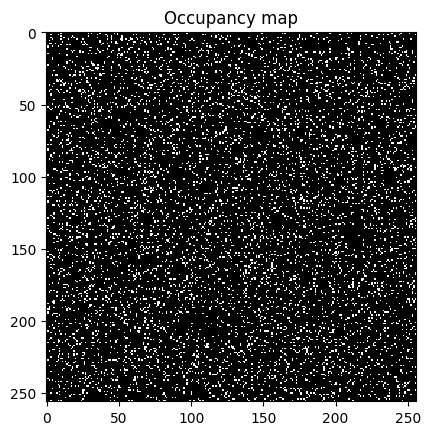

In [3]:
grid = np.random.rand(1024//4, 1024//4) > 0.9
cell_size = 4
grid_bbox = np.array([[0, 0], [1024, 1024]])

fig, ax = plt.subplots()

ax.imshow(grid, cmap='gray', interpolation='nearest', zorder=2)
ax.set_title("Occupancy map")
plt.show()

In [4]:
if isfile("grid_quad.quad.lp"): #Save and reuse quads
    quadt, field = lpio.loadQuadTreeFile("grid_quad.quad.lp", return_field=True)
else:
    field = lpio.loadOccupancyMap(grid, bbox=grid_bbox)
    quadt = larp.quad.QuadTree(field, minimum_length_limit=cell_size/4, edge_bounds=[])
    lpio.saveQuadTree(quadt, "grid_quad.quad.lp")

qfield = larp.QPotentailField(quadt) # Equivalent to field, but Speeds up some computations by using quad decomposition
path_planner = larp.pp.QuadPlanner(quadt, 'a*') # Set up a path planner based on quad decomposition

In [5]:
# Feasible start and end
start_point, end_point = (-1, -1), (260, 260)

# find path
path = path_planner.find_path(start_point=start_point, end_point=end_point)

print(f"Found path: {path is not None}")

Found path: True


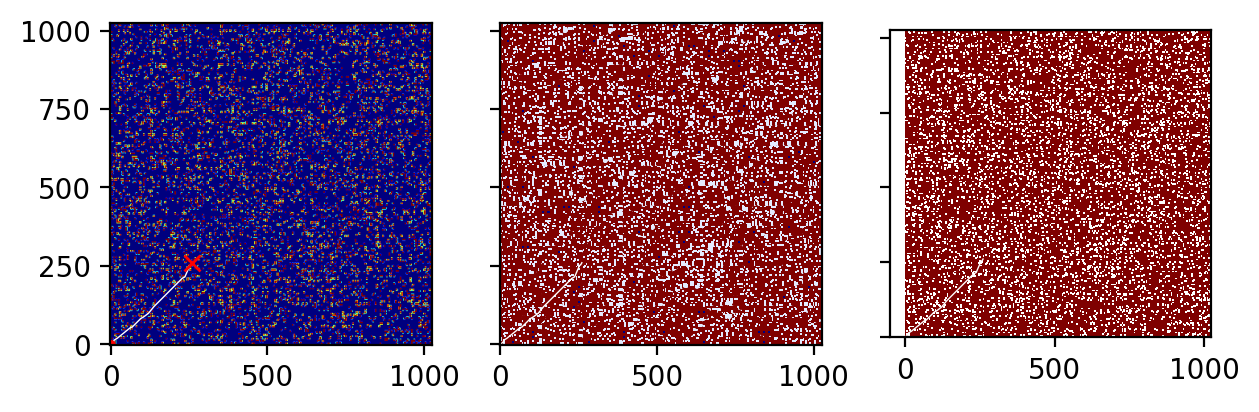

In [6]:
# Plot path in potential field
## May be slow due to graphics complexity
axs = plot(qfield, quadt, quad_offset=0.01)

if path is not None:
    axs[0].plot(*path.T, 'w', lw=0.5)
    axs[0].plot(*start_point, 'r.')
    axs[0].plot(*end_point, 'rx')
    axs[1].plot(*path.T, 'w', lw=0.5)
    axs[2].plot(*path.T, 'w', lw=0.5)

plt.show()